In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


In [14]:
print("loading MNIST dataset..")
X,y=fetch_openml(
    'mnist_784',
    version=1,
    return_X_y=True,
    as_frame=False
)
X=X.astype('float32')
y=y.astype('int')
print("Dataset loaded successfully!")
print("Total Samples:",X.shape[0])
print("Number of Features:",X.shape[1])

loading MNIST dataset..
Dataset loaded successfully!
Total Samples: 70000
Number of Features: 784


In [15]:
X=X/255.0
X=X[:20000]
y=y[:20000]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16000
Testing samples: 4000


In [16]:
activations=['logistic','relu','tanh']
results={}
training_times={}
accuracies={}

In [17]:
for activation in activations:
    print("\n--------------------------------------")
    print("Training with:",activation)
    print("----------------------------------------")
    start_time=time.time()
    model=MLPClassifier(
        hidden_layer_sizes=(128, ),
        activation=activation,
        solver='adam',
        max_iter=100,
        batch_size=128,
        random_state=42,
        verbose=False
    )
    model.fit(X_train,y_train)
    end_time=time.time()
    training_time=end_time-start_time
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    results[activation]=model
    training_times[activation]=training_time
    accuracies[activation]=accuracy*100
    print("Training time:{:.2f}seconds".format(training_time))
    print("Number of iterations:",model.n_iter_)
    print("Test accuracy:{:.2f}%".format(accuracy*100))


--------------------------------------
Training with: logistic
----------------------------------------
Training time:124.54seconds
Number of iterations: 99
Test accuracy:95.58%

--------------------------------------
Training with: relu
----------------------------------------
Training time:81.44seconds
Number of iterations: 56
Test accuracy:96.23%

--------------------------------------
Training with: tanh
----------------------------------------
Training time:76.11seconds
Number of iterations: 61
Test accuracy:95.80%


In [21]:
print("\n===============================================")
print("     ACTIVATION FUNCTION COMPARISON              ")
print("=================================================")
print("{:<12}{:<15}{:<15}".format(
    "Activation","Time(sec)","Iterations","Accuracy(%)"
))
for activation in activations:
    model=results[activation]
    print("{:<12}{:<15.2f}{:<15}{:<15.2f}".format(
        activation,
        training_times[activation],
        model.n_iter_,
        accuracies[activation]
    ))


     ACTIVATION FUNCTION COMPARISON              
Activation  Time(sec)      Iterations     
logistic    124.54         99             95.58          
relu        81.44          56             96.23          
tanh        76.11          61             95.80          


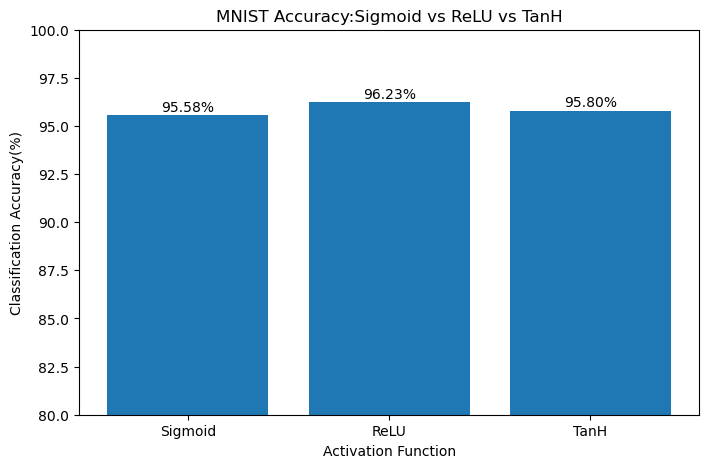

In [25]:
plt.figure(figsize=(8,5))
plt.bar(
    ['Sigmoid','ReLU','TanH'],
    [
        accuracies['logistic'],
        accuracies['relu'],
        accuracies['tanh']
    ]
)
plt.xlabel("Activation Function")
plt.ylabel("Classification Accuracy(%)")
plt.title("MNIST Accuracy:Sigmoid vs ReLU vs TanH")
plt.ylim(80,100)
for i, value in enumerate([
    accuracies['logistic'],
    accuracies['relu'],
    accuracies['tanh']
]):
    plt.text(i,value+0.2,f"{value:.2f}%",
             ha='center')
plt.show()

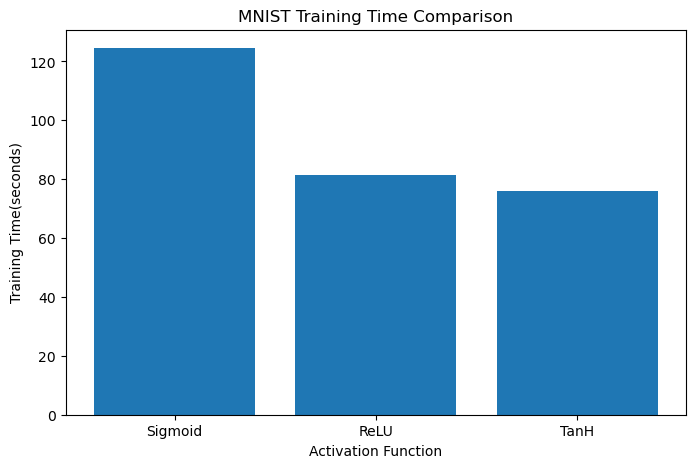

In [26]:
plt.figure(figsize=(8,5))
plt.bar(
    ['Sigmoid','ReLU','TanH'],
    [
        training_times['logistic'],
        training_times['relu'],
        training_times['tanh']
    ]
)
plt.xlabel("Activation Function")
plt.ylabel("Training Time(seconds)")
plt.title("MNIST Training Time Comparison")
plt.show()

In [ ]:
model=results[activation]
plt.plot(
    range(1,